# Cls 2. Intro to PyTorch. CNNs

In [1]:
import torch

1. Autograd

In [11]:
x = torch.tensor([1, 2, 3, 4], dtype=float, requires_grad=True)
x

tensor([1., 2., 3., 4.], dtype=torch.float64, requires_grad=True)

In [19]:
y = x * torch.exp(x) 
y

tensor([  2.7183,  14.7781,  60.2566, 218.3926], dtype=torch.float64,
       grad_fn=<MulBackward0>)

In [21]:
y.mean().backward()

In [22]:
x.grad

tensor([ 1.8591,  6.5418, 21.5855, 70.2477], dtype=torch.float64)

2. Accelerator support 

In [24]:
torch.cuda.is_available()

False

In [27]:
x = x.to("cpu")

## MLP

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from tqdm.auto import tqdm

In [41]:
class MLP(nn.Module):
    def __init__(self, d_in, d_out, d_hidden, depth=10):
        super().__init__()

        self.layers = nn.ModuleList(
            [nn.Linear(d_in, d_hidden)] + 
            [nn.Linear(d_hidden, d_hidden) for _ in range(depth - 1)]
        )
        self.relu = nn.ReLU()

        self.head = nn.Linear(d_hidden, d_out)
        self.sigm = nn.Sigmoid()

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
            x = self.relu(x)

        x = self.head(x)
        x = self.sigm(x)

        return x


In [43]:
data = pd.read_csv("data/cls1/points.csv", sep=' ', names=['x', 'y', 'cls'])
data.head()

,x,y,cls
0,1.699885,1.546782,1
1,1.641367,2.506392,1
2,2.408797,1.430931,1
3,3.255215,1.792221,1
4,2.361248,1.980791,1


In [57]:
x = torch.tensor(data[['x', 'y']].values, dtype=torch.float32)
x = (x - x.mean(0)) / x.std(0)
y_target = torch.tensor(data['cls'].values, dtype=torch.float32).unsqueeze(1)

In [ ]:
n_epochs = 1000
lr = 1e-2

loss_fn = nn.BCELoss()
model = MLP(2, 1, 10, 10)
optim = torch.optim.Adam(model.parameters(), lr=lr)

loss_history = []
for step in tqdm(range(n_epochs)):
    y = model(x)
    loss = loss_fn(y, y_target)

    loss_history.append(loss.item())

    optim.zero_grad() 
    loss.backward()
    optim.step()


  0%|          | 0/1000 [00:00<?, ?it/s]

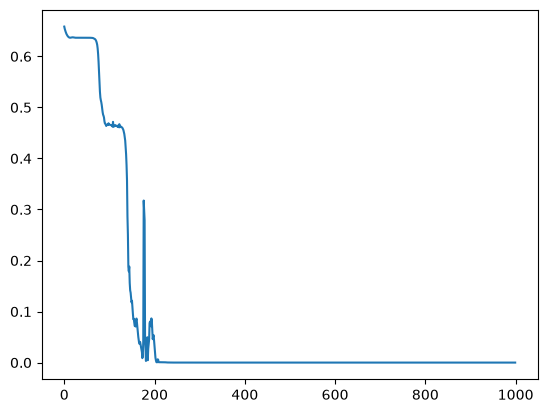

In [62]:
plt.plot(loss_history)

In [63]:
y_pred = model(x)

In [68]:
((y_pred > 0.5) == y_target).all()

tensor(True)

## Dataset & Dataloder

In [71]:
import torch
import torchvision
from torchvision.transforms import v2


transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

In [72]:
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
training_loader = torch.utils.data.DataLoader(training_set, batch_size=96, shuffle=True)

In [77]:
batch = next(iter(training_loader))

# Cls 2 (part 2). CNNs by hand

- **A.** Why an MLP is a poor fit for images
- **B.** What a convolution computes: one pixel, a loop version, `F.conv2d`, output shapes
- **C.** Convolution as a layer: hand-set weights, learning a filter, channels, 1x1 conv
- **D.** Other building blocks: ReLU, pooling, receptive field, BatchNorm, Dropout, the classification head
- **E.** Assemble a CNN, train it, compare with an MLP, look inside
- **F.** Extra, if time is left: residual block, depthwise conv, augmentation

## Setup

In [79]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torchinfo import summary
from sklearn.datasets import load_sample_image
from tqdm.auto import tqdm

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [80]:
def to_np(img):
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
    return np.asarray(img, dtype=float)


def show(img, title=None, ax=None, signed=False):
    # signed=True: red/blue colormap centered at 0 (for filters and edge maps)
    img = to_np(img)
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    if signed:
        m = np.abs(img).max() or 1.0
        ax.imshow(img, cmap="RdBu_r", vmin=-m, vmax=m)
    else:
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def show_row(imgs, titles=None, signed=False, size=2.5):
    n = len(imgs)
    signed = signed if isinstance(signed, (list, tuple)) else [signed] * n
    titles = titles or [None] * n
    _, axes = plt.subplots(1, n, figsize=(size * n, size))
    for ax, img, t, s in zip(np.atleast_1d(axes), imgs, titles, signed):
        show(img, t, ax=ax, signed=s)
    plt.show()


def show_grid(imgs, ncols=8, signed=False, size=1.2):
    n = len(imgs)
    nrows = (n + ncols - 1) // ncols
    _, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, img in zip(np.ravel(axes), imgs):
        show(img, ax=ax, signed=signed)
    plt.show()

Data: one photo from scikit-learn and FashionMNIST (28x28 grayscale, 10 classes).

(427, 640, 3) (427, 640) torch.Size([1000, 1, 28, 28])


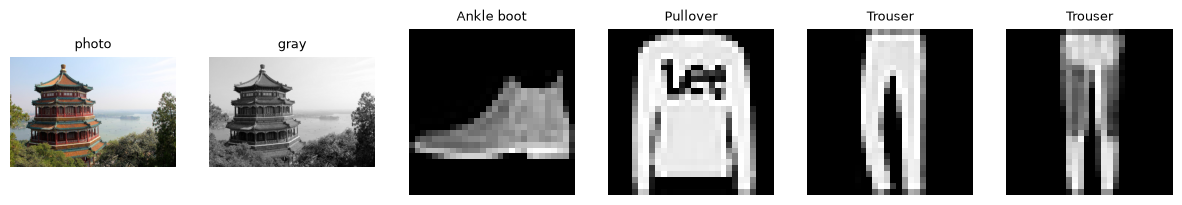

In [81]:
photo = load_sample_image("china.jpg").astype(np.float32) / 255      # (H, W, 3)
gray = photo @ np.array([0.299, 0.587, 0.114], dtype=np.float32)      # (H, W)

transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
train_set = torchvision.datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST("./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000)
classes = train_set.classes

x_batch, y_batch = next(iter(test_loader))   # (1000, 1, 28, 28), (1000,)
img = x_batch[0, 0]                          # one 28x28 image

print(photo.shape, gray.shape, x_batch.shape)
show_row([photo, gray] + [x_batch[i, 0] for i in range(4)],
         ["photo", "gray"] + [classes[y_batch[i]] for i in range(4)])

Training and evaluation helpers. Same loop as in the first half.

`accuracy(model, shift=k)` moves every test image `k` pixels right and down (`torch.roll`) before predicting. We use it at the end.

In [82]:
@torch.no_grad()
def accuracy(model, shift=0):
    model.eval()
    correct = 0
    for x, y in test_loader:
        x = torch.roll(x, shifts=(shift, shift), dims=(2, 3))
        correct += (model(x.to(device)).argmax(1).cpu() == y).sum().item()
    return correct / len(test_set)


def train(model, epochs=1, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        model.train()
        for x, y in tqdm(train_loader, desc=f"epoch {ep + 1}", leave=False):
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(model(x), y)
            opt.zero_grad()
            loss.backward()
            opt.step()
        print(f"epoch {ep + 1}: loss {loss.item():.3f}, test acc {accuracy(model):.3f}")


def n_params(model):
    return sum(p.numel() for p in model.parameters())

## A. Why an MLP is a poor fit for images

- **Flattening drops the 2D structure.** A 28x28 image becomes a vector of 784 numbers. If we shuffle the pixels with one fixed permutation, the MLP learns equally well. It does not use the fact that neighbouring pixels are related.
- **Too many parameters.** `Linear(784, 256)` already has about 200k weights. For a 224x224 RGB image and 1000 hidden units it is about 150M weights in the first layer alone.
- **No weight sharing.** An edge in the top-left corner and the same edge in the bottom-right corner are detected by different weights. Each position has to be learned separately from data.
- **No robustness to shifts.** Moving the object by a couple of pixels changes which weights see it. We measure this in exercise 15.
- **Locality.** Useful low-level features (edges, corners, textures) depend on a small neighbourhood of pixels. A fully connected layer looks at all pixels at once.
- **Hierarchy.** Objects are built from parts and parts from edges. Stacking local layers lets the model see a larger area at each level (receptive field, exercise 10).
- **Inductive bias.** A conv layer can be seen as a linear layer with two constraints: each output is connected only to a local patch, and the same weights are used at every position. Fewer parameters and a prior that fits images usually means better generalization from less data.

## B. What a convolution computes

### Exercise 1. One output pixel by hand

Take the 3x3 patch of the image with top-left corner at `(i, j)`. Multiply it element-wise with the kernel `k` and sum. That number is one pixel of the output.

The kernel below is **Sobel x**: right column minus left column, so it responds to vertical edges.

In [87]:
k = np.array([[-1, 0, 1],
              [-2, 0, 2],
              [-1, 0, 1]], dtype=np.float32)   # Sobel x
x = img.numpy()
i, j = 10, 12

patch = x[i:i+3, j:j+3]   # TODO: 3x3 slice of x starting at (i, j)
value = (patch * k).sum()  #  TODO: element-wise product with k, then sum
value

np.float32(0.52156866)

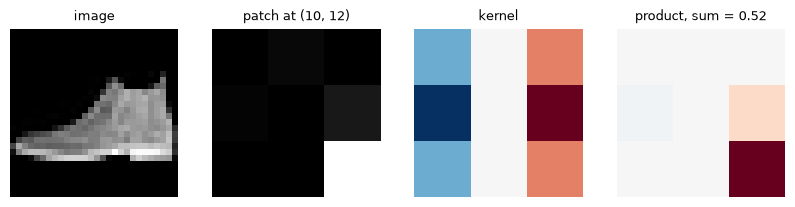

In [88]:
show_row([x, patch, k, patch * k], ["image", f"patch at ({i}, {j})", "kernel", f"product, sum = {value:.2f}"],
         signed=[False, False, True, True])

### Exercise 2. The whole image with two loops

Repeat exercise 1 for every position where the kernel fits fully inside the image ("valid" mode: no padding, stride 1). The output is `(H - kh + 1) x (W - kw + 1)`.

Note: strictly speaking this is **cross-correlation**. Mathematical convolution flips the kernel first. Deep learning libraries compute cross-correlation and call it convolution. For learned kernels the difference does not matter.

In [89]:
def conv2d(x, k):
    H, W = x.shape
    kh, kw = k.shape
    out = np.zeros((H - kh + 1, W - kw + 1), dtype=np.float32)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = (x[i:i + kh, j:j + kw] * k).sum()
    return out


assert np.isclose(conv2d(x, k)[i, j], value)

Now apply it to the photo (downsampled 2x so the Python loops are fast). Define two more kernels:

- **Sobel y**: the transpose of Sobel x, responds to horizontal edges.
- **Box blur 5x5**: all 25 weights equal, summing to 1 (a local average).

In [ ]:
small = gray[::2, ::2]
sobel_x = k
sobel_y = ...   # TODO
blur = ...      # TODO

gx, gy = conv2d(small, sobel_x), conv2d(small, sobel_y)
show_row([small, gx, gy, np.sqrt(gx ** 2 + gy ** 2), conv2d(small, blur)],
         ["input", "Sobel x", "Sobel y", "edge magnitude", "box blur 5x5"],
         signed=[False, True, True, False, False], size=3.5)

### Exercise 3. The same with `F.conv2d`

PyTorch works with batches of multi-channel images:

- input: `(N, C_in, H, W)`: batch, channels, height, width
- weight: `(C_out, C_in, kh, kw)`: one `C_in x kh x kw` filter per output channel
- output: `(N, C_out, H_out, W_out)`

Convert `small` and `sobel_x` to these layouts and compare with our loop version.

In [ ]:
xt = ...   # TODO: tensor of shape (1, 1, H, W)
wt = ...   # TODO: tensor of shape (1, 1, 3, 3)
out = F.conv2d(xt, wt)

print(xt.shape, wt.shape, out.shape)
assert np.allclose(out[0, 0].numpy(), gx, atol=1e-4)

In [ ]:
%timeit conv2d(small, sobel_x)
%timeit F.conv2d(xt, wt)

### Exercise 4. Output shape: padding and stride

- **padding** `p`: add `p` rows/columns of zeros on each side,
- **stride** `s`: move the kernel `s` pixels at a time.

$$ n_{out} = \left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1 $$

Write `out_size`. Before running the loop, predict each line out loud. Question: which `p` keeps the size unchanged for `k = 3, 5, 7`?

In [ ]:
def out_size(n, k, p=0, s=1):
    return ...   # TODO


x28 = torch.randn(1, 1, 28, 28)
for k_, p, s in [(3, 0, 1), (3, 1, 1), (5, 2, 1), (3, 1, 2), (7, 0, 3)]:
    real = F.conv2d(x28, torch.randn(1, 1, k_, k_), padding=p, stride=s).shape[-1]
    print(f"k={k_} p={p} s={s}: predicted {out_size(28, k_, p, s)}, real {real}")

## C. Convolution as a layer

### Exercise 5. Set the weights of `nn.Conv2d` by hand

`nn.Conv2d` stores its kernels in `.weight` (a learnable parameter) and has an optional `.bias`. Create a layer with 2 output channels and copy Sobel x into channel 0 and Sobel y into channel 1.

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, padding=1, bias=False)
print(conv.weight.shape)

with torch.no_grad():
    ...   # TODO: put sobel_x into output channel 0 and sobel_y into output channel 1

feats = conv(img[None, None])   # (1, 2, 28, 28)
show_row([img, feats[0, 0], feats[0, 1]], ["input", "channel 0", "channel 1"], signed=[False, True, True])

### Exercise 6. Learn the filter with gradient descent

Here the weights were designed by hand. In a CNN they are learned. Check that this works on a toy problem: the target is the output of our Sobel layer, the model is a conv layer with random weights, the loss is MSE. Write the training step.

In [ ]:
x = x_batch[:64]
with torch.no_grad():
    target = conv(x)                      # fixed Sobel layer from exercise 5

student = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
w_init = student.weight.detach().clone()
opt = torch.optim.Adam(student.parameters(), lr=0.05)

losses = []
for step in range(300):
    # TODO: forward, MSE loss against target, zero_grad, backward, step; append loss.item() to losses
    ...

plt.figure(figsize=(4, 2.5)); plt.plot(losses); plt.yscale("log"); plt.title("MSE"); plt.show()
show_row([w_init[0, 0], w_init[1, 0], student.weight[0, 0], student.weight[1, 0], conv.weight[0, 0], conv.weight[1, 0]],
         ["init 0", "init 1", "learned 0", "learned 1", "target 0", "target 1"], signed=True, size=2)
print(student.weight.detach().round(decimals=2))

### Exercise 7. Several input channels

For an RGB input each filter has shape `(C_in, k, k)`: it covers all input channels at once. Output channel `o` is

$$ \text{out}_o = \sum_{c=1}^{C_{in}} \text{conv2d}(x_c, W_{o,c}) + b_o $$

**7a.** Predict the number of parameters of `nn.Conv2d(3, 8, kernel_size=3)` before computing it. Compare with `nn.Linear` on a flattened 64x64x3 image with 8 outputs.

In [ ]:
conv_rgb = nn.Conv2d(3, 8, kernel_size=3)

my_guess = ...   # TODO: a formula with numbers, not n_params(...)
print(conv_rgb.weight.shape, conv_rgb.bias.shape)
assert my_guess == n_params(conv_rgb)
print("Linear(64*64*3, 8):", n_params(nn.Linear(64 * 64 * 3, 8)))

**7b.** Check the summation rule: compute output channel `o` with our loop `conv2d` from exercise 2.

In [ ]:
crop = photo[100:164, 200:264]                      # (64, 64, 3)
xt = torch.tensor(crop).permute(2, 0, 1)[None]      # (1, 3, 64, 64)
out = conv_rgb(xt)                                  # (1, 8, 62, 62)

W = conv_rgb.weight.detach().numpy()
b = conv_rgb.bias.detach().numpy()
o = 5
manual = ...   # TODO: sum over the 3 input channels of conv2d(crop[:, :, c], W[o, c]), plus b[o]
assert np.allclose(manual, out[0, o].detach().numpy(), atol=1e-4)

**7c.** A **1x1 convolution** looks at one pixel only, so it mixes channels and does nothing spatially. Write the RGB to grayscale conversion `0.299 R + 0.587 G + 0.114 B` as a `Conv2d(3, 1, kernel_size=1)`.

In [ ]:
to_gray = nn.Conv2d(3, 1, kernel_size=1, bias=False)
with torch.no_grad():
    ...   # TODO: set to_gray.weight (what is its shape?)

photo_t = torch.tensor(photo).permute(2, 0, 1)[None]
g = to_gray(photo_t)[0, 0].detach()
assert np.allclose(g.numpy(), gray, atol=1e-5)
show_row([photo, g], ["RGB", "1x1 conv"], size=3.5)

## D. Other building blocks 

### Exercise 8. Nonlinearity

**8a.** Apply ReLU to the Sobel x map from exercise 5. Which edges remain?

In [ ]:
edges = feats[0, 0].detach()
relu_edges = ...   # TODO
show_row([img, edges, relu_edges], ["input", "Sobel x", "ReLU(Sobel x)"], signed=[False, True, True])

**8b.** Without an activation, two stacked convs are still a linear map (and equal to a single bigger conv). Check linearity, `f(x1 + x2) == f(x1) + f(x2)`, for a stack with and without ReLU.

In [ ]:
c1 = nn.Conv2d(1, 4, 3, bias=False)
c2 = nn.Conv2d(4, 1, 3, bias=False)
no_act = nn.Sequential(c1, c2)
with_act = nn.Sequential(c1, nn.ReLU(), c2)
x1, x2 = x_batch[:1], x_batch[1:2]

for name, f in [("no activation", no_act), ("with ReLU", with_act)]:
    is_linear = ...   # TODO: torch.allclose(...)
    print(name, is_linear)

### Exercise 9. Pooling

**9a.** Compute the 2x2 max pooling (stride 2) of `A` in your head, then check with `F.max_pool2d`.

In [ ]:
A = torch.tensor([[1., 3, 2, 0],
                  [4, 2, 1, 1],
                  [0, 1, 5, 6],
                  [2, 2, 7, 3]])

my_answer = torch.tensor(...)   # TODO: 2x2 result
assert torch.equal(my_answer, F.max_pool2d(A[None, None], 2)[0, 0])

**9b.** Pooling halves the resolution and makes the result less sensitive to small shifts. Shift the edge map by 1 pixel and compare the change before and after pooling. Use the relative difference `||a - b|| / ||a||`.

In [ ]:
fmap = relu_edges[None]                      # (1, 28, 28)
fmap_shift = torch.roll(fmap, 1, dims=-1)    # shifted 1 px to the right

def rel_diff(a, b):
    return ((a - b).norm() / a.norm()).item()

before = ...   # TODO: rel_diff of the two maps
after = ...    # TODO: rel_diff after F.max_pool2d(..., 2) of each map
print(f"before pooling: {before:.2f}, after pooling: {after:.2f}")

### Exercise 10. Receptive field

The receptive field of an output pixel is the set of input pixels it depends on. We can find it with autograd: take one output pixel in the center, call `backward()`, and see which input pixels got a nonzero gradient.

Fill in the helper, then predict the size for each stack before running. All weights are set to 1 so that no gradients cancel by accident. We use average pooling here: with max pooling the gradient goes to only one pixel per window, which depends on the input.

In [ ]:
def receptive_field(model, size=31):
    x = torch.zeros(1, 1, size, size, requires_grad=True)
    y = model(x)
    c = y.shape[-1] // 2
    # TODO: backward from the center output pixel y[0, 0, c, c]
    mask = ...   # TODO: where x.grad is nonzero
    return mask


def stack(*layers):
    m = nn.Sequential(*layers)
    for p in m.parameters():
        nn.init.ones_(p)
    return m


conv3 = lambda **kw: nn.Conv2d(1, 1, 3, padding=1, bias=False, **kw)
models = {
    "1 conv": stack(conv3()),
    "2 convs": stack(conv3(), conv3()),
    "3 convs": stack(conv3(), conv3(), conv3()),
    "conv s=2, conv": stack(conv3(stride=2), conv3()),
    "conv, avgpool, conv": stack(conv3(), nn.AvgPool2d(2), conv3()),
}
masks = {name: receptive_field(m) for name, m in models.items()}
show_row(list(masks.values()), [f"{n}: {int(m.any(0).sum())}px" for n, m in masks.items()], size=2.3)

Questions:

- Each extra 3x3 conv adds 2 pixels. How many 3x3 layers do we need to see a whole 28x28 image without downsampling?
- Why does a stride-2 layer (or pooling) make the following layers grow the receptive field faster?

### Exercise 11. BatchNorm

`nn.BatchNorm2d(C)` normalizes each channel using the mean and variance over the batch and spatial dimensions `(N, H, W)`, then applies a learnable scale and shift (initialized to 1 and 0). Reproduce the train-mode output by hand.

In [ ]:
bn = nn.BatchNorm2d(4)
x = torch.randn(16, 4, 8, 8) * 3 + 5

bn.train()
y = bn(x)

mean = ...       # TODO: per-channel mean, keepdim=True so it broadcasts
var = ...        # TODO: per-channel variance, unbiased=False
y_manual = ...   # TODO: use bn.eps
assert torch.allclose(y, y_manual, atol=1e-5)

In eval mode BatchNorm does not use the batch statistics. It uses running averages collected during training (`running_mean`, `running_var`, updated with `momentum=0.1`). This is why `model.eval()` matters at test time.

In [ ]:
print("running_mean after one batch:", bn.running_mean)
bn.eval()
y_eval = bn(x)
print("train-mode output mean/std:", y.mean().item(), y.std().item())
print("eval-mode  output mean/std:", y_eval.mean().item(), y_eval.std().item())

### Exercise 12. Dropout

Apply `nn.Dropout(p=0.5)` to a tensor of ones in train mode and in eval mode. Why are the kept values equal to 2?

In [ ]:
drop = nn.Dropout(p=0.5)
ones = torch.ones(2, 10)
# TODO: print drop(ones) after drop.train(), then after drop.eval()

### Exercise 13. The classification head: Flatten vs global average pooling

After the conv layers we have a feature map, e.g. `(64, 7, 7)`, and need 10 class scores. Two options:

- `Flatten` + `Linear`: one weight per channel and per position,
- global average pooling (`AdaptiveAvgPool2d(1)`): average each channel over all positions, then `Linear`.

Fill in the input sizes of the linear layers, compare parameter counts, then feed a bigger feature map (what we get from a bigger input image).

In [ ]:
feat = torch.randn(1, 64, 7, 7)
head_flat = nn.Sequential(nn.Flatten(), nn.Linear(..., 10))                            # TODO
head_gap = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(..., 10))   # TODO

print("params flat:", n_params(head_flat), " params gap:", n_params(head_gap))
print(head_flat(feat).shape, head_gap(feat).shape)

big = torch.randn(1, 64, 10, 10)
for name, head in [("flat", head_flat), ("gap", head_gap)]:
    try:
        print(name, head(big).shape)
    except RuntimeError as e:
        print(name, "error:", str(e).splitlines()[0])

## E. Put it together

### Exercise 14. Build and train a CNN

Use the blocks from above. Write the shapes next to each block; `summary` will check them.

- block 1: conv 1→32 (3x3, padding 1), BatchNorm, ReLU, MaxPool 2 → `(32, 14, 14)`
- block 2: conv 32→64, same pattern → `(64, 7, 7)`
- block 3: conv 64→128, BatchNorm, ReLU (no pooling) → `(128, 7, 7)`
- head: global average pooling, Flatten, Dropout 0.3, Linear 128→10

In [ ]:
cnn = nn.Sequential(
    # TODO
)
summary(cnn, input_size=(1, 1, 28, 28))

In [ ]:
train(cnn, epochs=2)

An MLP baseline, similar to the first half, trained the same way.

In [ ]:
mlp = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
train(mlp, epochs=2)

### Exercise 15. CNN vs MLP

Compare the number of parameters and the test accuracy when every test image is shifted by 0 to 4 pixels (`accuracy(model, shift=s)`). Plot both curves.

In [ ]:
shifts = range(5)
results = {}
for name, model in [("CNN", cnn), ("MLP", mlp)]:
    results[name] = ...   # TODO: list of accuracies for each shift
    print(f"{name}: {n_params(model):,} params, acc {results[name]}")

plt.figure(figsize=(4, 3))
for name, accs in results.items():
    plt.plot(shifts, accs, "o-", label=name)
plt.xlabel("shift, px"); plt.ylabel("test accuracy"); plt.legend(); plt.show()

After 2 epochs both models are at a similar accuracy on unshifted images (about 82 to 87% in our runs; the exact number varies between runs), and the CNN has half the parameters. Under shifts both curves go down: max pooling and global average pooling give only partial shift invariance, and the model never saw shifted images during training. The MLP drops much faster because every pixel position has its own weights.

Questions:

- Replace the global average pooling head with `MaxPool2d(2)` + `Flatten` + `Linear`. Accuracy without a shift goes up (about 90% in our runs). What do you expect for shifted images, and why?
- How would you make the CNN more robust to shifts without changing the architecture? (See F3.)

### Exercise 16. Look inside

**16a.** Plot the 32 first-layer kernels (`cnn[0].weight`, shape `(32, 1, 3, 3)`).

**16b.** Plot the 32 feature maps after block 1 for one image (run the image through `cnn[:4]`).

In [ ]:
cnn.eval().cpu()

kernels = ...   # TODO: (32, 3, 3)
show_grid(kernels, signed=True)

show(img, classes[y_batch[0]])
with torch.no_grad():
    maps = ...   # TODO: (32, 14, 14)
show_grid(maps)

## F. Extra, if time is left

### F1. Residual block

A residual block computes `relu(x + f(x))`, where `f` is conv-BN-ReLU-conv-BN. If the number of channels changes, `x` and `f(x)` have different shapes, and the shortcut becomes a 1x1 conv.

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.f = ...          # TODO: conv3x3 c_in->c_out, BN, ReLU, conv3x3 c_out->c_out, BN (padding 1)
        self.shortcut = ...   # TODO: nn.Identity() if c_in == c_out, else a 1x1 conv c_in->c_out

    def forward(self, x):
        return ...            # TODO


print(ResBlock(32, 32)(torch.randn(2, 32, 14, 14)).shape)
print(ResBlock(32, 64)(torch.randn(2, 32, 14, 14)).shape)

### F2. Depthwise separable convolution

`groups=C` makes each filter see only its own input channel (depthwise). Followed by a 1x1 conv that mixes channels, this replaces a regular 3x3 conv with far fewer parameters (used in MobileNet). Compare parameter counts for 64→128 channels.

In [ ]:
regular = nn.Conv2d(64, 128, 3, padding=1)
separable = nn.Sequential(
    ...,   # TODO: depthwise 3x3, 64->64, groups=64
    ...,   # TODO: pointwise 1x1, 64->128
)
x = torch.randn(1, 64, 14, 14)
print(regular(x).shape, separable(x).shape)
print(f"regular: {n_params(regular):,}, separable: {n_params(separable):,}")

### F3. Data augmentation

Random transformations of training images teach the model the invariances we want. Build a transform with a random shift (`v2.RandomAffine(degrees=0, translate=...)`) and a horizontal flip, and look at what it produces for one image. To use it in training, pass it as `transform=` to the training dataset and rerun exercise 14 and 15.

In [ ]:
augment = v2.Compose([
    # TODO
])
show_row([img] + [augment(img[None])[0] for _ in range(7)], ["original"] + [""] * 7, size=1.8)